In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
import random as _random
import json
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

In [2]:
%run "2_3_dataset_transforms.ipynb"

C:\Users\Lenovo\Desktop\project 2\project2\14_resNet\newData\dataset\train -> True
C:\Users\Lenovo\Desktop\project 2\project2\14_resNet\newData\dataset\clean -> True
C:\Users\Lenovo\Desktop\project 2\project2\14_resNet\newData\datasetv2_TrainClean\train -> True
C:\Users\Lenovo\Desktop\project 2\project2\14_resNet\newData\datasetv2_TrainClean\clean -> True

 newData\dataset\train
Classes: ['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'savari', 'taxi', 'vanet']

 newData\dataset\clean
Classes: ['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'savari', 'taxi', 'vanet']

 newData\datasetv2_TrainClean\train
Classes: ['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'savari', 'taxi', 'vanet']

 newData\datasetv2_TrainClean\clean
Classes: ['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'savari', 'taxi', 'vanet']
Total number of images: 3313

Number by class:
label
savari       498
kamyun       493
taxi         484
autobus      464
kamyunet     456
minibu

---

## Recovery — Reload everything from saved files

In [3]:
BACKBONE_LR = 0.0001
HEAD_LR = 0.001
SPLIT_SEED = 42

BASE_DIR = Path("newData")
OUTPUT_DIR = BASE_DIR / "resnet_data_splits"
MODELS_DIR = Path("saved_models")
NEYSAN_OOD_DIR = BASE_DIR / "neysan_ood"
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# ---- Reload the split CSV instead of recomputing audit/dedup/split ----
inventory_split_df = pd.read_csv(OUTPUT_DIR / "inventory_train_val_split.csv")

MERGE_MAP = {"kamyun": "truck_merged", "kamyunet": "truck_merged"}
inventory_split_df["coarse_label"] = inventory_split_df["label"].replace(MERGE_MAP)


# ---- Rebuild class mappings (deterministic, will match exactly) ----
COARSE_CLASS_NAMES = sorted(inventory_split_df["coarse_label"].unique())
COARSE_CLASS_TO_IDX = {name: idx for idx, name in enumerate(COARSE_CLASS_NAMES)}
COARSE_IDX_TO_CLASS = {idx: name for name, idx in COARSE_CLASS_TO_IDX.items()}
NUM_COARSE_CLASSES = len(COARSE_CLASS_TO_IDX)

cascade_df = inventory_split_df[inventory_split_df["label"].isin(["kamyun", "kamyunet"])].reset_index(drop=True)
CASCADE_CLASS_NAMES = sorted(cascade_df["label"].unique())
CASCADE_CLASS_TO_IDX = {name: idx for idx, name in enumerate(CASCADE_CLASS_NAMES)}
CASCADE_IDX_TO_CLASS = {idx: name for name, idx in CASCADE_CLASS_TO_IDX.items()}
NUM_CASCADE_CLASSES = len(CASCADE_CLASS_TO_IDX)

print("\nCoarse classes:", COARSE_CLASS_TO_IDX)
print("Cascade classes:", CASCADE_CLASS_TO_IDX)

# ---- Dataloaders needed going forward ----
coarse_val_dataset = VehicleDataset(val_df, COARSE_CLASS_TO_IDX, label_col="coarse_label", transform=val_transform)
coarse_val_loader = DataLoader(coarse_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"\nCoarse validation dataloader rebuilt: {len(coarse_val_dataset)} samples")

# ---- Rebuild model architectures and load saved weights ----
def build_resnet18(num_classes, mode="feature_extraction"):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if mode == "feature_extraction":
        for param in model.parameters():
            param.requires_grad = False
    elif mode == "fine_tuning":
        for param in model.parameters():
            param.requires_grad = True
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

coarse_model_ft_weighted = build_resnet18(NUM_COARSE_CLASSES, mode="fine_tuning")
coarse_model_ft_weighted.load_state_dict(
    torch.load(MODELS_DIR / "coarse_resnet18_fine_tuning_weighted.pt", map_location=DEVICE)
)
coarse_model_ft_weighted = coarse_model_ft_weighted.to(DEVICE)
coarse_model_ft_weighted.eval()

cascade_model = build_resnet18(NUM_CASCADE_CLASSES, mode="fine_tuning")
cascade_model.load_state_dict(
    torch.load(MODELS_DIR / "cascade_resnet18_kamyun_kamyunet.pt", map_location=DEVICE)
)
cascade_model = cascade_model.to(DEVICE)
cascade_model.eval()

print("\nBoth models rebuilt and weights loaded successfully from disk.")
print("No retraining needed — ready to continue from Step 16 (threshold calibration).")


Coarse classes: {'ambulance': 0, 'autobus': 1, 'minibus': 2, 'savari': 3, 'taxi': 4, 'truck_merged': 5, 'vanet': 6}
Cascade classes: {'kamyun': 0, 'kamyunet': 1}

Coarse validation dataloader rebuilt: 664 samples

Both models rebuilt and weights loaded successfully from disk.
No retraining needed — ready to continue from Step 16 (threshold calibration).


## Calibration threshold with neysan_ood
### 6.1 — Load neysan_ood images and inventory them

In [4]:
NEYSAN_OOD_DIR = BASE_DIR / "neysan_ood"
neysan_files = [
    f for f in NEYSAN_OOD_DIR.rglob("*")
    if f.is_file() and f.suffix.lower() in VALID_EXTENSIONS
]
print(f"Total neysan_ood images found: {len(neysan_files)}")

Total neysan_ood images found: 554


### 6.2 — Split neysan_ood into a calibration subset and a phase-2 test subset

In [5]:
NEYSAN_CALIBRATION_RATIO = 0.5  # نیمی برای کالیبراسیون آستانه و نیمی برای آزمون مرحله دوم.

_random.seed(SPLIT_SEED)
neysan_files_shuffled = neysan_files.copy()
_random.shuffle(neysan_files_shuffled)

split_point = int(len(neysan_files_shuffled) * NEYSAN_CALIBRATION_RATIO)
neysan_calibration_files = neysan_files_shuffled[:split_point]
neysan_phase2_test_files = neysan_files_shuffled[split_point:]

print(f"Calibration subset: {len(neysan_calibration_files)} images")
print(f"Phase-2 test subset: {len(neysan_phase2_test_files)} images")

phase2_list_path = OUTPUT_DIR / "neysan_phase2_test_files.csv"
pd.DataFrame({"filepath": [str(f) for f in neysan_phase2_test_files]}).to_csv(phase2_list_path, index=False)
print(f"\nPhase-2 test file list saved to: {phase2_list_path}")

Calibration subset: 277 images
Phase-2 test subset: 277 images

Phase-2 test file list saved to: newData\resnet_data_splits\neysan_phase2_test_files.csv


### 6.3 — Compute coarse-model confidence on known validation images vs. neysan calibration images

In [6]:
def get_max_softmax_confidences(model, image_paths, transform, device):
    """
    مدل اولیه (coarse model) را روی فهرستی از مسیرهای فایل‌های تصویری اجرا می‌کند و
    بیشینه احتمال سافت‌مکس (میزان اطمینان) را برای هر تصویر بازمی‌گرداند.
    """
    model.eval()
    confidences = []

    with torch.no_grad():
        for path in image_paths:
            image = Image.open(path).convert("RGB")
            input_tensor = transform(image).unsqueeze(0).to(device)
            logits = model(input_tensor)
            probs = F.softmax(logits, dim=1).squeeze(0).cpu().numpy()
            confidences.append(float(probs.max()))

    return np.array(confidences)

known_val_confidences = get_max_softmax_confidences(
    coarse_model_ft_weighted, val_df["filepath"].tolist(), val_transform, DEVICE
)
neysan_calibration_confidences = get_max_softmax_confidences(
    coarse_model_ft_weighted, neysan_calibration_files, val_transform, DEVICE
)
print("Known validation confidence distribution:")
print(f"  mean={known_val_confidences.mean():.4f}  min={known_val_confidences.min():.4f}  "
      f"p10={np.percentile(known_val_confidences, 10):.4f}  p25={np.percentile(known_val_confidences, 25):.4f}")

print("\nNeysan (OOD) calibration confidence distribution:")
print(f"  mean={neysan_calibration_confidences.mean():.4f}  max={neysan_calibration_confidences.max():.4f}  "
      f"p75={np.percentile(neysan_calibration_confidences, 75):.4f}  p90={np.percentile(neysan_calibration_confidences, 90):.4f}")

Known validation confidence distribution:
  mean=0.9876  min=0.3860  p10=0.9899  p25=0.9983

Neysan (OOD) calibration confidence distribution:
  mean=0.9521  max=1.0000  p75=0.9998  p90=1.0000


### 6.4 — Threshold sweep: compare flagged rates on known vs. neysan across candidate thresholds

In [7]:
candidate_thresholds = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.97, 0.99, 0.995, 0.999]

print(f"{'Threshold':>10} | {'Known FPR (wrongly flagged)':>30} | {'Neysan TPR (correctly flagged)':>32}")
print("-" * 78)

for t in candidate_thresholds:
    known_fpr = (known_val_confidences < t).mean()
    neysan_tpr = (neysan_calibration_confidences < t).mean()
    print(f"{t:>10.3f} | {known_fpr:>29.2%} | {neysan_tpr:>31.2%}")

 Threshold |    Known FPR (wrongly flagged) |   Neysan TPR (correctly flagged)
------------------------------------------------------------------------------
     0.500 |                         0.30% |                           1.81%
     0.600 |                         0.90% |                           4.69%
     0.700 |                         1.81% |                           7.58%
     0.800 |                         2.11% |                           9.03%
     0.900 |                         2.26% |                          13.36%
     0.950 |                         3.92% |                          15.88%
     0.970 |                         5.12% |                          19.86%
     0.990 |                        10.09% |                          29.24%
     0.995 |                        15.51% |                          36.82%
     0.999 |                        29.67% |                          54.87%


# Adding `need_review` to the Inference function and saving the threshold

### 6.5 — Save the calibrated threshold and its justification to disk

In [8]:
CONFIDENCE_THRESHOLD = 0.99
threshold_record = {
    "confidence_threshold": CONFIDENCE_THRESHOLD,
    "known_false_positive_rate": 0.1009,
    "neysan_true_positive_rate": 0.2924,
    "known_set_size": len(val_df),
    "neysan_calibration_set_size": len(neysan_calibration_files),
}
threshold_path = MODELS_DIR / "confidence_threshold.json"
with open(threshold_path, "w") as f:
    json.dump(threshold_record, f, indent=2)

print(f"Threshold record saved to: {threshold_path}")
print(json.dumps(threshold_record, indent=2))

Threshold record saved to: saved_models\confidence_threshold.json
{
  "confidence_threshold": 0.99,
  "known_false_positive_rate": 0.1009,
  "neysan_true_positive_rate": 0.2924,
  "known_set_size": 664,
  "neysan_calibration_set_size": 277
}


### 6.6 — Extend predict_vehicle to include the needs_review flag

In [9]:
def predict_vehicle(image, coarse_model, cascade_model, coarse_idx_to_class,
                     cascade_idx_to_class, transform, device, confidence_threshold):
    """
    full two-stage pipeline: coarse model, then cascade for truck_merged
    وقتی اطمینان به کمتر از آستانه اطمینان می‌رسد، یک flag needs_review اضافه می‌کند.
    """
    coarse_model.eval()
    cascade_model.eval()

    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        coarse_logits = coarse_model(input_tensor)
        coarse_probs = F.softmax(coarse_logits, dim=1).squeeze(0).cpu().numpy()

    coarse_pred_idx = int(coarse_probs.argmax())
    coarse_pred_class = coarse_idx_to_class[coarse_pred_idx]
    coarse_confidence = float(coarse_probs[coarse_pred_idx])

    result = {
        "coarse_prediction": coarse_pred_class,
        "coarse_probs": {coarse_idx_to_class[i]: float(p) for i, p in enumerate(coarse_probs)},
    }

    if coarse_pred_class != "truck_merged":
        result["predicted_class"] = coarse_pred_class
        result["confidence"] = coarse_confidence
        result["cascade_probs"] = None
        result["needs_review"] = coarse_confidence < confidence_threshold
        return result

    with torch.no_grad():
        cascade_logits = cascade_model(input_tensor)
        cascade_probs = F.softmax(cascade_logits, dim=1).squeeze(0).cpu().numpy()

    cascade_pred_idx = int(cascade_probs.argmax())
    cascade_pred_class = cascade_idx_to_class[cascade_pred_idx]
    cascade_confidence = float(cascade_probs[cascade_pred_idx])

    final_confidence = coarse_confidence * cascade_confidence

    result["predicted_class"] = cascade_pred_class
    result["confidence"] = final_confidence
    result["cascade_probs"] = {cascade_idx_to_class[i]: float(p) for i, p in enumerate(cascade_probs)}
    result["needs_review"] = final_confidence < confidence_threshold
    return result

### 6.7 — Quick sanity check: known validation samples vs. neysan samples

In [10]:
print("Known validation samples (expect mostly needs_review=False):\n")
sample_known = val_df.sample(n=5, random_state=SPLIT_SEED)
for _, row in sample_known.iterrows():
    img = Image.open(row["filepath"]).convert("RGB")
    pred = predict_vehicle(
        img, coarse_model_ft_weighted, cascade_model,
        COARSE_IDX_TO_CLASS, CASCADE_IDX_TO_CLASS,
        val_transform, DEVICE, CONFIDENCE_THRESHOLD,
    )
    print(f"  true={row['label']:12s} predicted={pred['predicted_class']:12s} "
          f"confidence={pred['confidence']:.4f}  needs_review={pred['needs_review']}")

print("\nNeysan samples (expect a mix, mostly needs_review=False per our analysis):\n")
sample_neysan = _random.sample(neysan_calibration_files, 5)
for f in sample_neysan:
    img = Image.open(f).convert("RGB")
    pred = predict_vehicle(
        img, coarse_model_ft_weighted, cascade_model,
        COARSE_IDX_TO_CLASS, CASCADE_IDX_TO_CLASS,
        val_transform, DEVICE, CONFIDENCE_THRESHOLD,
    )
    print(f"  predicted={pred['predicted_class']:12s} confidence={pred['confidence']:.4f}  "
          f"needs_review={pred['needs_review']}")

Known validation samples (expect mostly needs_review=False):

  true=kamyun       predicted=kamyun       confidence=0.9999  needs_review=False
  true=kamyunet     predicted=kamyunet     confidence=0.9996  needs_review=False
  true=kamyun       predicted=kamyun       confidence=0.9992  needs_review=False
  true=autobus      predicted=autobus      confidence=1.0000  needs_review=False
  true=autobus      predicted=autobus      confidence=0.9918  needs_review=False

Neysan samples (expect a mix, mostly needs_review=False per our analysis):

  predicted=vanet        confidence=1.0000  needs_review=False
  predicted=vanet        confidence=0.9996  needs_review=False
  predicted=vanet        confidence=0.9997  needs_review=False
  predicted=vanet        confidence=0.9997  needs_review=False
  predicted=vanet        confidence=0.9982  needs_review=False


---
## comprehensive evaluation of Phase 1 and Phase 2 final testing
### 6.8 — Build test inventory for phase 1 (8 known classes, no neysan)

In [11]:
TEST_DIR = BASE_DIR / "dataTest" / "test"
test_records = []
for class_dir in sorted(TEST_DIR.iterdir()):
    if not class_dir.is_dir():
        continue
    label = class_dir.name
    for f in class_dir.rglob("*"):
        if f.is_file() and f.suffix.lower() in VALID_EXTENSIONS:
            test_records.append({"filepath": str(f), "label": label})

test_df = pd.DataFrame(test_records)

print(f"Phase 1 test set size: {len(test_df)}")
print("\nClass counts:")
print(test_df["label"].value_counts())

Phase 1 test set size: 365

Class counts:
label
ambulance    50
autobus      50
kamyun       50
kamyunet     50
minibus      50
savari       50
taxi         50
vanet        15
Name: count, dtype: int64


### 6.9 — Run the full cascade pipeline on every phase-1 test image

In [12]:
def run_pipeline_on_dataframe(df, coarse_model, cascade_model, coarse_idx_to_class,
                                cascade_idx_to_class, transform, device, confidence_threshold):
    """
    تابع predict_vehicle را روی تک‌تک سطرهای df (که باید دارای ستونی به نام filepath باشد) اجرا می‌کند
    و نتایج را در قالب یک دیتافریم جدید که ستون‌های پیش‌بینی به آن اضافه شده‌اند، بازمی‌گرداند.
    """
    predictions = []
    confidences = []
    needs_review_flags = []

    for filepath in df["filepath"]:
        image = Image.open(filepath).convert("RGB")
        result = predict_vehicle(
            image, coarse_model, cascade_model,
            coarse_idx_to_class, cascade_idx_to_class,
            transform, device, confidence_threshold,
        )
        predictions.append(result["predicted_class"])
        confidences.append(result["confidence"])
        needs_review_flags.append(result["needs_review"])

    result_df = df.copy()
    result_df["predicted_class"] = predictions
    result_df["confidence"] = confidences
    result_df["needs_review"] = needs_review_flags
    return result_df


test_results_df = run_pipeline_on_dataframe(
    test_df, coarse_model_ft_weighted, cascade_model,
    COARSE_IDX_TO_CLASS, CASCADE_IDX_TO_CLASS,
    val_transform, DEVICE, CONFIDENCE_THRESHOLD,
)

print("Pipeline run complete on phase-1 test set.")
print(test_results_df[["label", "predicted_class", "confidence", "needs_review"]].head(10))

Pipeline run complete on phase-1 test set.
       label predicted_class  confidence  needs_review
0  ambulance           vanet    0.776162          True
1  ambulance       ambulance    0.994625         False
2  ambulance       ambulance    0.999607         False
3  ambulance       ambulance    0.999925         False
4  ambulance       ambulance    0.999303         False
5  ambulance       ambulance    0.999885         False
6  ambulance       ambulance    0.999762         False
7  ambulance       ambulance    0.999853         False
8  ambulance       ambulance    0.983243          True
9  ambulance       ambulance    0.999963         False


### 7.1 — Phase 1 metrics: full 8-class classification report and confusion matrix

In [13]:
ALL_8_CLASSES = sorted(test_df["label"].unique())

phase1_report = classification_report(
    test_results_df["label"], test_results_df["predicted_class"],
    labels=ALL_8_CLASSES, target_names=ALL_8_CLASSES, digits=4,
)
print("=== PHASE 1 — Test set, 8 known classes, no neysan ===\n")
print(phase1_report)

phase1_cm = confusion_matrix(
    test_results_df["label"], test_results_df["predicted_class"], labels=ALL_8_CLASSES
)
print("\nConfusion matrix (rows = true, columns = predicted):")
print("Class order:", ALL_8_CLASSES)
print(phase1_cm)

phase1_review_rate = test_results_df["needs_review"].mean()
print(f"\nPhase 1 needs_review rate (false-alarm rate on known data): {phase1_review_rate:.2%}")

=== PHASE 1 — Test set, 8 known classes, no neysan ===

              precision    recall  f1-score   support

   ambulance     1.0000    0.9400    0.9691        50
     autobus     1.0000    1.0000    1.0000        50
      kamyun     1.0000    0.9400    0.9691        50
    kamyunet     0.9615    1.0000    0.9804        50
     minibus     0.9804    1.0000    0.9901        50
      savari     0.9615    1.0000    0.9804        50
        taxi     1.0000    0.9600    0.9796        50
       vanet     0.8333    1.0000    0.9091        15

    accuracy                         0.9781       365
   macro avg     0.9671    0.9800    0.9722       365
weighted avg     0.9799    0.9781    0.9783       365


Confusion matrix (rows = true, columns = predicted):
Class order: ['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'savari', 'taxi', 'vanet']
[[47  0  0  0  0  1  0  2]
 [ 0 50  0  0  0  0  0  0]
 [ 0  0 47  2  1  0  0  0]
 [ 0  0  0 50  0  0  0  0]
 [ 0  0  0  0 50  0  0  0]
 [ 0  

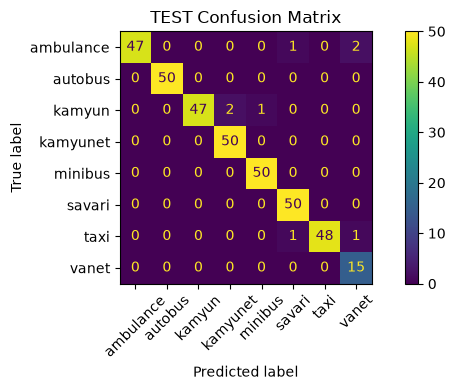

In [14]:
classes = [
    'ambulance',
    'autobus',
    'kamyun',
    'kamyunet',
    'minibus',
    'savari',
    'taxi',
    'vanet'
]
disp = ConfusionMatrixDisplay(
    confusion_matrix=phase1_cm,
    display_labels=classes
)
fig, ax = plt.subplots(figsize=(7, 4))
disp.plot(
    ax=ax,
    xticks_rotation=45
)
plt.title("TEST Confusion Matrix")
plt.tight_layout()
plt.show()

--- 

## Phase 2 — Testing with Nissan
### 7.2 — Build phase-2 inventory (phase-1 test + neysan phase-2 subset)

In [15]:
neysan_phase2_df = pd.DataFrame({
    "filepath": [str(f) for f in neysan_phase2_test_files],
    "label": "neysan",  # نه یک کلاس آموزش‌دیده — صرفاً برای ثبت و نگهداری سوابق حفظ شده و
                             # هرگز به عنوان حقیقت مبنا به کار نرفته .
})
print(f"Neysan phase-2 subset size: {len(neysan_phase2_df)}")

Neysan phase-2 subset size: 277


### 7.3 — Run the pipeline on the neysan phase-2 subset

In [16]:
neysan_phase2_results_df = run_pipeline_on_dataframe(
    neysan_phase2_df, coarse_model_ft_weighted, cascade_model,
    COARSE_IDX_TO_CLASS, CASCADE_IDX_TO_CLASS,
    val_transform, DEVICE, CONFIDENCE_THRESHOLD,
)
print("Pipeline run complete on neysan phase-2 subset.")
print(neysan_phase2_results_df[["predicted_class", "confidence", "needs_review"]].head(10))

Pipeline run complete on neysan phase-2 subset.
  predicted_class  confidence  needs_review
0           vanet    0.773347          True
1           vanet    0.594807          True
2           vanet    0.998259         False
3           vanet    0.996554         False
4           vanet    0.999961         False
5           vanet    0.999984         False
6           vanet    0.999949         False
7           vanet    0.997727         False
8           vanet    0.999657         False
9           vanet    0.999989         False


### 7.4 — Phase 2 summary: prediction distribution, confidence stats, and review rate on neysan vs. known

In [17]:
print("=== PHASE 2 — Neysan (unseen class) behavior ===\n")

print("Prediction distribution on neysan images:")
print(neysan_phase2_results_df["predicted_class"].value_counts())

print(f"\nMean confidence on neysan predictions: {neysan_phase2_results_df['confidence'].mean():.4f}")

neysan_review_rate = neysan_phase2_results_df["needs_review"].mean()
print(f"\nNeysan needs_review rate: {neysan_review_rate:.2%}")
print(f"Phase 1 (known) needs_review rate: {phase1_review_rate:.2%}")
print(f"Difference: {(neysan_review_rate - phase1_review_rate):.2%} percentage points")

=== PHASE 2 — Neysan (unseen class) behavior ===

Prediction distribution on neysan images:
predicted_class
vanet      258
minibus      9
savari       9
autobus      1
Name: count, dtype: int64

Mean confidence on neysan predictions: 0.9538

Neysan needs_review rate: 27.44%
Phase 1 (known) needs_review rate: 13.42%
Difference: 14.01% percentage points


---

## Error Analysis
### 8.1 — Isolate all misclassified images from the phase-1 test results

In [18]:
misclassified_df = test_results_df[
    test_results_df["label"] != test_results_df["predicted_class"]
].copy()

print(f"Total test images: {len(test_results_df)}")
print(f"Total misclassified: {len(misclassified_df)}")
print(f"Error rate: {len(misclassified_df) / len(test_results_df):.2%}")

print("\nAll misclassified cases:")
print(misclassified_df[["filepath", "label", "predicted_class", "confidence", "needs_review"]].to_string(index=False))

Total test images: 365
Total misclassified: 8
Error rate: 2.19%

All misclassified cases:
                                     filepath     label predicted_class  confidence  needs_review
newData\dataTest\test\ambulance\197398569.jpg ambulance           vanet    0.776162          True
newData\dataTest\test\ambulance\215936132.jpg ambulance           vanet    0.999620         False
newData\dataTest\test\ambulance\218107250.jpg ambulance          savari    0.512531          True
   newData\dataTest\test\kamyun\215662509.jpg    kamyun         minibus    0.905573          True
   newData\dataTest\test\kamyun\216034399.jpg    kamyun        kamyunet    0.661806          True
   newData\dataTest\test\kamyun\218618273.jpg    kamyun        kamyunet    0.999821         False
     newData\dataTest\test\taxi\216563328.jpg      taxi           vanet    0.772174          True
     newData\dataTest\test\taxi\216649147.jpg      taxi          savari    0.553846          True


### 8.2 — Count error patterns (true label | wrong prediction)

In [22]:
error_patterns = misclassified_df.groupby(["label", "predicted_class"]).size().reset_index(name="count")
error_patterns = error_patterns.sort_values("count", ascending=False)

print("Error patterns (true | predicted):\n")
print(error_patterns.to_string(index=False))

Error patterns (true | predicted):

    label predicted_class  count
ambulance           vanet      2
   kamyun        kamyunet      2
ambulance          savari      1
   kamyun         minibus      1
     taxi          savari      1
     taxi           vanet      1


### 8.3 — Visually inspect the misclassified images

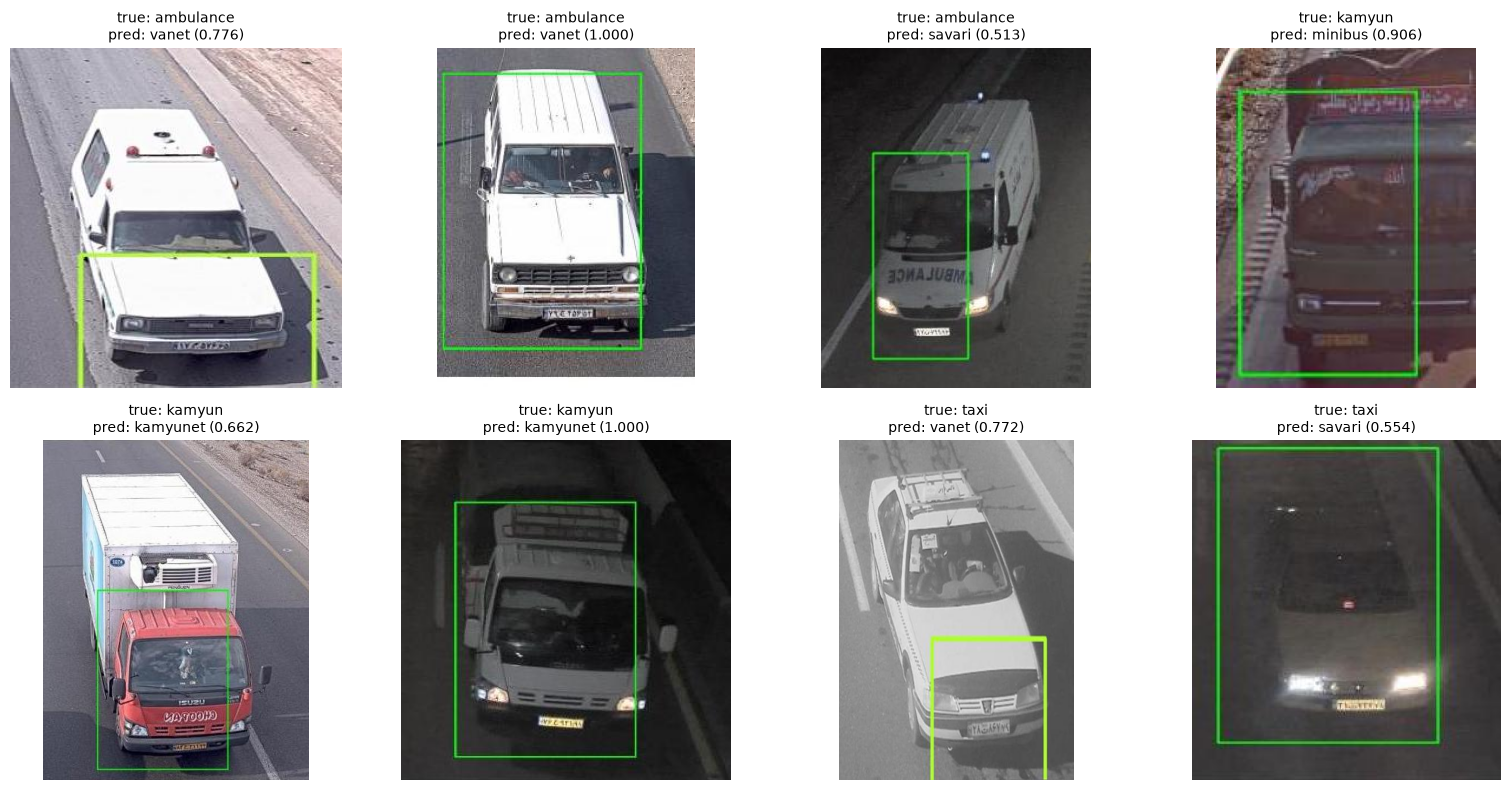

In [27]:
num_errors = len(misclassified_df)
cols = 4
rows = (num_errors + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten() if num_errors > 1 else [axes]

for i, (_, row) in enumerate(misclassified_df.iterrows()):
    img = Image.open(row["filepath"]).convert("RGB")
    axes[i].imshow(img)
    axes[i].set_title(
        f"true: {row['label']}\npred: {row['predicted_class']} ({row['confidence']:.3f})",
        fontsize=10,
    )
    axes[i].axis("off")

for j in range(num_errors, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()